In [10]:
# train_bezier_ode.py
# Requires: pip install torch
import torch
import numpy as np

torch.set_default_dtype(torch.float64)
device = torch.device("cpu")
ITERATIONS=100
# --------------------------
# Provided parameter endpoints (v1, v2)
# --------------------------
v1 = torch.tensor([1.5e-02, 0.0, 2.0e+02, 1.8e+02, 1.8e-02, 0.0, 1.0, 0.6, 1.0e+02, 5.0e+01, 1.0],
                  dtype=torch.float64, device=device)
v2 = torch.tensor([1.16000589e-02, 0.0, 5.02761655e+02, 5.74579613e+02, 1.24596408e-02, 0.0, 1.64052318, 8.22972056, 1.0e+02, 5.0e+01, 1.0],
                  dtype=torch.float64, device=device)

assert v1.shape == v2.shape and v1.ndim == 1
P = v1.shape[0]

# --------------------------
# time grid for simulation and loss integral
# --------------------------
T = 100.0             # simulation horizon, adjust to your problem
sim_steps = 10000      # number of RK4 steps for each trajectory (increased for stiff system)
dt = T / sim_steps
time_grid = torch.linspace(0.0, T, sim_steps + 1, dtype=torch.float64, device=device)

# --------------------------
# initial condition x0 and (placeholder) data; you should replace x0 and x_data if you have measurements
# --------------------------
# state is [C2, CP, pM, M, Y, YP] (6-dim vector)
x0 = torch.tensor([0.9, 0.05, 0.0, 0.005, 0.3, 0.0], dtype=torch.float64, device=device)

# --------------------------
# ODE function f(state, p_vec)
# p_vec is length 11; mapping of indices to names (assumption)
# index mapping (assumed):
# 0:k1_aa_over_CT, 1:k2, 2:k3_CT, 3:k4, 4:k4prime, 5:k5_minusP, 6:k6, 7:k7, 8:k8_minusP, 9:k9, 10:CT
# --------------------------
def f_torch(state, p_vec):
    # state: tensor length 6
    C2, CP, pM, M, Y, YP = state[0], state[1], state[2], state[3], state[4], state[5]

    k1_aa_over_CT = p_vec[0]
    k2 = p_vec[1]
    k3_CT = p_vec[2]
    k4 = p_vec[3]
    k4prime = p_vec[4]
    k5_minusP = p_vec[5]
    k6 = p_vec[6]
    k7 = p_vec[7]
    k8_minusP = p_vec[8]
    k9 = p_vec[9]
    CT = p_vec[10]

    # follow original formulas (small adjustments to avoid div by zero)
    # original used k3 = p["k3_CT"]/p["CT"] and k1 = p["k1_aa_over_CT"] * p['CT']
    k3 = k3_CT / (CT + 1e-12)
    k1 = k1_aa_over_CT * CT

    # F_M
    FM = k4prime + k4 * (M / (CT + 1e-12))**2

    # rates
    dC2 = k6 * M - k8_minusP * C2 + k9 * CP
    dCP = -k3 * CP * Y + k8_minusP * C2 - k9 * CP
    dpM = k3 * CP * Y - pM * FM + k5_minusP * M
    dM  = pM * FM - k5_minusP * M - k6 * M
    dY  = k1 - k2 * Y - k3 * CP * Y
    dYP = k6 * M - k7 * YP

    return torch.stack([dC2, dCP, dpM, dM, dY, dYP])

# --------------------------
# Simple RK4 integrator (returns whole trajectory as (steps+1, state_dim) tensor)
# --------------------------
def rk4_trajectory(p_vec, x0, T, steps):
    dt = T / steps
    x = x0
    traj = [x0]
    for _ in range(steps):
        k1 = f_torch(x, p_vec)
        k2 = f_torch(x + 0.5 * dt * k1, p_vec)
        k3 = f_torch(x + 0.5 * dt * k2, p_vec)
        k4 = f_torch(x + dt * k3, p_vec)
        x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        traj.append(x)
    return torch.stack(traj, dim=0)  # shape (steps+1, 6)

# --------------------------
# Precompute x_data(t) = 0.5*(x(t;v1) + x(t;v2)) on the same time grid
# This is the "target" curve you described
# --------------------------
with torch.no_grad():
    traj1 = rk4_trajectory(v1, x0, T, sim_steps)   # (sim_steps+1, 6)
    traj2 = rk4_trajectory(v2, x0, T, sim_steps)
    x_data = 0.5 * (traj1 + traj2)                  # tensor (sim_steps+1, 6)

# --------------------------
# Bézier curve phi_theta(t) (theta is a vector length P)
# --------------------------
def phi_theta_scalar_t(t_scalar, theta_vec):
    # t_scalar in [0,1] (python float or 0-dim tensor)
    t = t_scalar if torch.is_tensor(t_scalar) else torch.tensor(t_scalar, dtype=torch.float64, device=device)
    return (1.0 - t)**2 * v1 + 2.0 * t * (1.0 - t) * theta_vec + t**2 * v2

# --------------------------
# Loss L(p) = integral_0^T (1/(Nc·Ns·Tc·σ²)) * ||x(t;p) - x_data(t)||^2 dt
# We'll implement the integrand sum over discrete grid; normalization factor we set as 1/(state_dim)
# You can replace norm_factor with your chosen constants; here we average over state dims and time.
# --------------------------
state_dim = 6
norm_factor = 1.0 / (state_dim)   # you can scale by 1/(Nc·Ns·Tc·σ²) if you have those values

def trajectory_loss(p_vec, x_data):
    traj = rk4_trajectory(p_vec, x0, T, sim_steps)  # (steps+1, 6), differentiable
    # squared errors at each time
    sq = (traj - x_data).pow(2).sum(dim=1)   # shape (steps+1,)
    # integrate with trapezoid rule
    integral = (0.5 * (sq[0] + sq[-1]) + sq[1:-1].sum()) * dt
    return norm_factor * integral

# --------------------------
# Training loop: optimize theta (the control point)
# --------------------------
def train_theta(num_iters=ITERATIONS, lr=1e-2):
    # init theta as midpoint in parameter space (you can also init randomly)
    theta = ((v1 + v2) / 2.0).clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([theta], lr=lr)

    for it in range(num_iters):
        # sample a random t in [0,1] for a stochastic estimate of the curve loss
        t_sample = torch.rand(1, dtype=torch.float64, device=device).item()

        p_vec = phi_theta_scalar_t(t_sample, theta)     # length-11 vector
        loss = trajectory_loss(p_vec, x_data)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if it % 50 == 0 or it == num_iters - 1:
            # diagnostic: estimate mean curve loss by evaluating several t
            with torch.no_grad():
                ts = torch.linspace(0.0, 1.0, 9, dtype=torch.float64, device=device)
                eval_losses = []
                for tt in ts:
                    p_eval = phi_theta_scalar_t(tt, theta)
                    eval_losses.append(trajectory_loss(p_eval, x_data).item())
                mean_curve_loss = float(np.mean(eval_losses))
            print(f"iter {it:4d} t={t_sample:.3f} loss_sample={loss.item():.6e} mean_curve_loss≈{mean_curve_loss:.6e}")

    return theta.detach()

if __name__ == "__main__":
    theta_opt = train_theta(num_iters=ITERATIONS, lr=5e-3)
    print("optimized theta:", theta_opt.cpu().numpy())




iter    0 t=0.871 loss_sample=2.607317e-01 mean_curve_loss≈2.702327e-01


KeyboardInterrupt: 

In [ ]:
# Modified training loop with loss tracking and visualization
def train_theta_with_tracking(num_iters=ITERATIONS, lr=1e-2):
    # init theta as midpoint in parameter space
    theta = ((v1 + v2) / 2.0).clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([theta], lr=lr)
    
    # Track losses
    loss_history = []
    mean_loss_history = []
    iterations = []

    for it in range(num_iters):
        # sample a random t in [0,1] for a stochastic estimate of the curve loss
        t_sample = torch.rand(1, dtype=torch.float64, device=device).item()

        p_vec = phi_theta_scalar_t(t_sample, theta)     # length-11 vector
        loss = trajectory_loss(p_vec, x_data)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if it % 10 == 0 or it == num_iters - 1:
            # diagnostic: estimate mean curve loss by evaluating several t
            with torch.no_grad():
                ts = torch.linspace(0.0, 1.0, 9, dtype=torch.float64, device=device)
                eval_losses = []
                for tt in ts:
                    p_eval = phi_theta_scalar_t(tt, theta)
                    eval_losses.append(trajectory_loss(p_eval, x_data).item())
                mean_curve_loss = float(np.mean(eval_losses))
            
            loss_history.append(loss.item())
            mean_loss_history.append(mean_curve_loss)
            iterations.append(it)
            
            if it % 50 == 0 or it == num_iters - 1:
                print(f"iter {it:4d} t={t_sample:.3f} loss_sample={loss.item():.6e} mean_curve_loss≈{mean_curve_loss:.6e}")

    # Plot training progress
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Loss over iterations
    ax1.plot(iterations, loss_history, 'o-', label='Sample loss', alpha=0.6, markersize=3)
    ax1.plot(iterations, mean_loss_history, 's-', label='Mean curve loss', linewidth=2)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Progress')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Plot 2: Trajectory comparison at a few points along the optimized curve
    with torch.no_grad():
        t_points = [0.0, 0.25, 0.5, 0.75, 1.0]
        colors = plt.cm.viridis(np.linspace(0, 1, len(t_points)))
        
        for t_val, color in zip(t_points, colors):
            p_vec = phi_theta_scalar_t(t_val, theta)
            traj = rk4_trajectory(p_vec, x0, T, sim_steps)
            # Plot M (active MPF) as a representative state
            M = traj[:, 3].cpu().numpy()
            t_plot = time_grid.cpu().numpy()
            ax2.plot(t_plot, M, label=f't={t_val:.2f}', color=color, linewidth=1.5)
        
        # Also plot the endpoint trajectories
        ax2.plot(t_plot, traj1[:, 3].cpu().numpy(), 'b--', label='v1 (t=0)', linewidth=2, alpha=0.5)
        ax2.plot(t_plot, traj2[:, 3].cpu().numpy(), 'r--', label='v2 (t=1)', linewidth=2, alpha=0.5)
    
    ax2.set_xlabel('Time')
    ax2.set_ylabel('M (Active MPF)')
    ax2.set_title('Trajectories along optimized Bézier curve')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return theta.detach(), loss_history, mean_loss_history

# Run training with tracking
print("Training with visualization...")
theta_opt, loss_hist, mean_loss_hist = train_theta_with_tracking(num_iters=ITERATIONS, lr=5e-3)
print("\nOptimized theta:", theta_opt.cpu().numpy())
print(f"\nFinal mean curve loss: {mean_loss_hist[-1]:.6e}")
print(f"Initial mean curve loss: {mean_loss_hist[0]:.6e}")
print(f"Improvement: {(mean_loss_hist[0] - mean_loss_hist[-1]) / mean_loss_hist[0] * 100:.2f}%")

In [ ]:
# Plot trajectories to verify what we're fitting
# Similar to Tyson plots but showing the target vs optimized curve trajectories
import matplotlib.pyplot as plt

CT = 1.0  # from v1 and v2

# Get trajectories at a few points along the optimized curve
with torch.no_grad():
    t_samples = [0.0, 0.25, 0.5, 0.75, 1.0]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    # State variable names
    state_names = ['C2', 'CP', 'pM', 'M', 'Y', 'YP']
    colors = plt.cm.viridis(np.linspace(0, 1, len(t_samples)))
    
    for idx, (ax, name) in enumerate(zip(axes, state_names)):
        # Plot target (average trajectory)
        t_plot = time_grid.cpu().numpy()
        ax.plot(t_plot, x_data_np[:, idx], 'k--', linewidth=3, 
                label='x_data (target)', alpha=0.7, zorder=10)
        
        # Plot trajectories at different points along the Bezier curve
        for t_val, color in zip(t_samples, colors):
            p_vec = phi_theta_scalar_t(t_val, theta_opt)
            traj = rk4_trajectory(p_vec, x0, T, sim_steps)
            traj_np = traj.cpu().numpy()
            ax.plot(t_plot, traj_np[:, idx], color=color, linewidth=1.5, 
                    label=f'φ(t={t_val:.2f})', alpha=0.8)
        
        ax.set_xlabel('Time (min)')
        ax.set_ylabel(name)
        ax.set_title(f'State: {name}')
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Target vs Optimized Bezier Curve Trajectories', 
                 y=1.02, fontsize=14, weight='bold')
    plt.show()

# Now make a plot similar to Tyson's: YT and M on log scale
with torch.no_grad():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    t_plot = time_grid.cpu().numpy()
    
    # Compute YT and M for target
    Y_data = x_data_np[:, 4]
    YP_data = x_data_np[:, 5]
    pM_data = x_data_np[:, 2]
    M_data = x_data_np[:, 3]
    YT_data = Y_data + YP_data + pM_data + M_data
    
    # Left plot: Linear scale
    ax1.plot(t_plot, YT_data / CT, 'k--', linewidth=3, label='[YT]/[CT] target', alpha=0.7)
    ax1.plot(t_plot, M_data / CT, 'gray', linewidth=3, linestyle='--', 
             label='[M]/[CT] target', alpha=0.7)
    
    for t_val, color in zip(t_samples, colors):
        p_vec = phi_theta_scalar_t(t_val, theta_opt)
        traj = rk4_trajectory(p_vec, x0, T, sim_steps)
        traj_np = traj.cpu().numpy()
        
        Y = traj_np[:, 4]
        YP = traj_np[:, 5]
        pM = traj_np[:, 2]
        M = traj_np[:, 3]
        YT = Y + YP + pM + M
        
        ax1.plot(t_plot, YT / CT, color=color, linewidth=1.5, 
                label=f'[YT]/[CT] φ(t={t_val:.2f})', alpha=0.8)
        ax1.plot(t_plot, M / CT, color=color, linewidth=1.0, 
                linestyle=':', alpha=0.6)
    
    ax1.set_xlim(0, T)
    ax1.set_xlabel('time (min)')
    ax1.set_ylabel('relative concentration')
    ax1.set_title('Linear Scale')
    ax1.legend(fontsize='small', loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Log scale (like Tyson Fig 3b)
    ax2.semilogy(t_plot, YT_data / CT, 'k--', linewidth=3, label='[YT]/[CT] target', alpha=0.7)
    ax2.semilogy(t_plot, M_data / CT, 'gray', linewidth=3, linestyle='--', 
                 label='[M]/[CT] target', alpha=0.7)
    
    for t_val, color in zip(t_samples, colors):
        p_vec = phi_theta_scalar_t(t_val, theta_opt)
        traj = rk4_trajectory(p_vec, x0, T, sim_steps)
        traj_np = traj.cpu().numpy()
        
        Y = traj_np[:, 4]
        YP = traj_np[:, 5]
        pM = traj_np[:, 2]
        M = traj_np[:, 3]
        YT = Y + YP + pM + M
        
        ax2.semilogy(t_plot, YT / CT, color=color, linewidth=1.5, 
                    label=f'[YT]/[CT] φ(t={t_val:.2f})', alpha=0.8)
        ax2.semilogy(t_plot, M / CT, color=color, linewidth=1.0, 
                    linestyle=':', alpha=0.6)
    
    ax2.set_xlim(0, T)
    ax2.set_ylim(1e-3, 1)
    ax2.set_xlabel('time (min)')
    ax2.set_ylabel('relative concentration (log scale)')
    ax2.set_title('Log Scale (Tyson-style)')
    ax2.legend(fontsize='small', loc='best')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Target vs Optimized Curve: [YT] and [M] observables', 
                 y=1.00, fontsize=14, weight='bold')
    plt.show()

iter    0 t=0.495 loss_sample=2.017802e-04 mean_curve_loss≈1.481690e-04
iter   50 t=0.451 loss_sample=1.198860e-04 mean_curve_loss≈9.108011e-05
iter  100 t=0.478 loss_sample=1.225033e-04 mean_curve_loss≈8.895608e-05
iter  150 t=0.536 loss_sample=1.466793e-04 mean_curve_loss≈9.240593e-05
iter  200 t=0.019 loss_sample=5.070526e-05 mean_curve_loss≈8.962499e-05
iter  250 t=0.806 loss_sample=1.321081e-04 mean_curve_loss≈9.628168e-05
iter  300 t=0.238 loss_sample=4.094715e-05 mean_curve_loss≈8.638957e-05
iter  350 t=0.720 loss_sample=1.630406e-04 mean_curve_loss≈8.497909e-05
iter  400 t=0.850 loss_sample=1.348519e-04 mean_curve_loss≈8.603429e-05
iter  450 t=0.495 loss_sample=1.098746e-04 mean_curve_loss≈8.486334e-05
iter  500 t=0.818 loss_sample=1.484115e-04 mean_curve_loss≈8.066706e-05
iter  550 t=0.812 loss_sample=1.499782e-04 mean_curve_loss≈7.773641e-05
iter  599 t=0.202 loss_sample=2.785172e-05 mean_curve_loss≈7.544093e-05
optimized theta: [ 1.15169571e-02  1.06881001e+00  3.50406346e+0

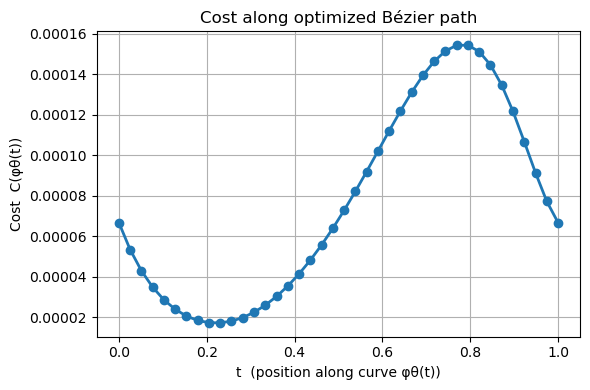

In [ ]:
import matplotlib.pyplot as plt

# --- Evaluate and plot cost along the learned curve ---
def evaluate_curve_cost(theta_vec, num_points=40):
    ts = torch.linspace(0.0, 1.0, num_points, dtype=torch.float64, device=device)
    costs = []
    with torch.no_grad():
        for tt in ts:
            p_vec = phi_theta_scalar_t(tt, theta_vec)
            cost = trajectory_loss(p_vec, x_data)
            costs.append(cost.item())
    return ts.cpu().numpy(), np.array(costs)

if __name__ == "__main__":
    theta_opt = train_theta(num_iters=ITERATIONS, lr=5e-3)
    print("optimized theta:", theta_opt.cpu().numpy())

    # Evaluate cost along the optimized curve
    ts, costs = evaluate_curve_cost(theta_opt, num_points=40)

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(ts, costs, "-o", lw=2)
    plt.xlabel("t  (position along curve φθ(t))")
    plt.ylabel("Cost  C(φθ(t))")
    plt.title("Cost along optimized Bézier path")
    plt.grid(True)
    plt.tight_layout()
    plt.show()




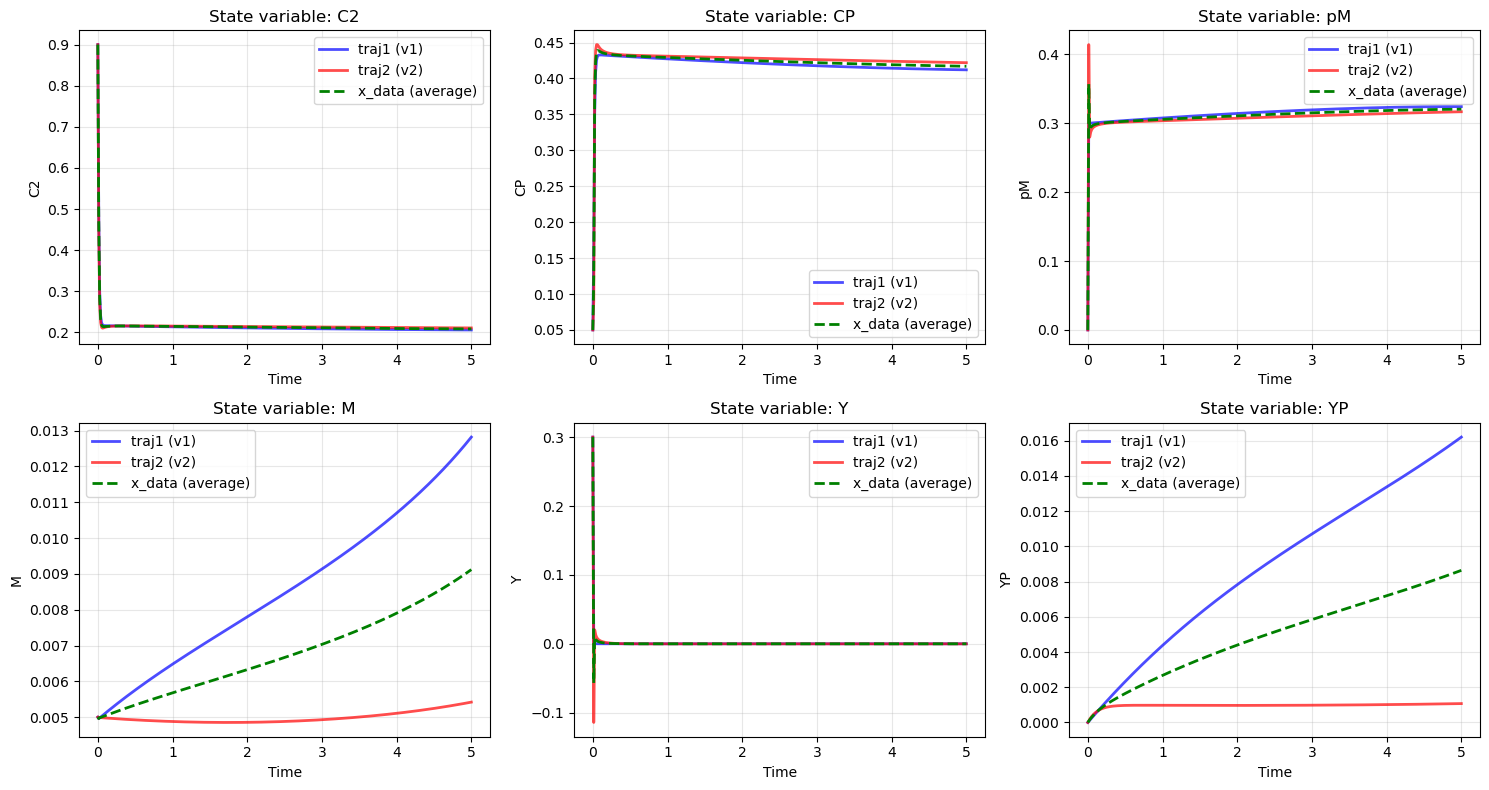

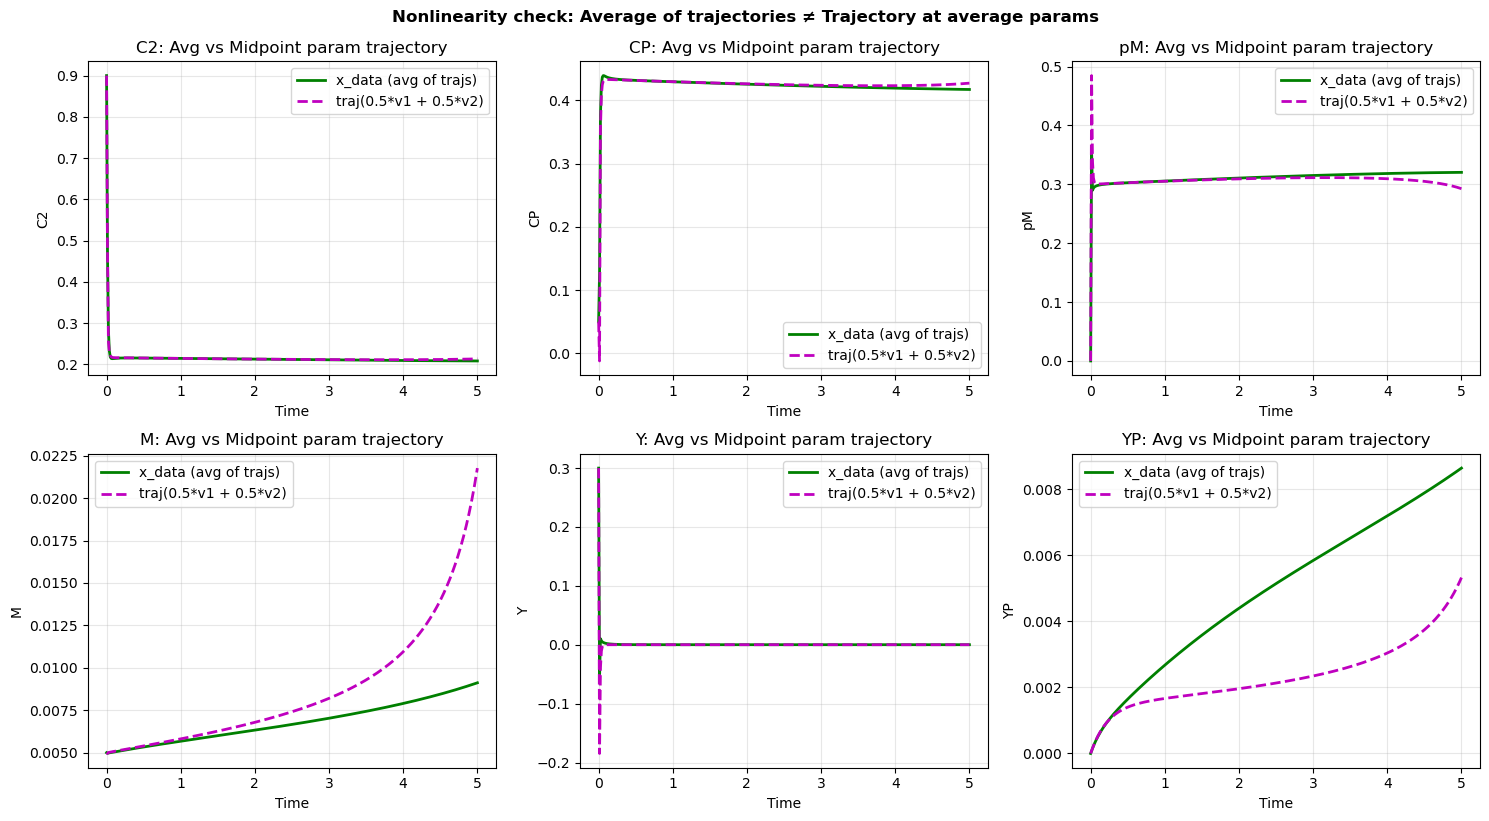

In [ ]:
# Plot the trajectories: traj1, traj2, and their average (x_data)
import matplotlib.pyplot as plt

# Convert to numpy for plotting
t_plot = time_grid.cpu().numpy()
traj1_np = traj1.cpu().numpy()
traj2_np = traj2.cpu().numpy()
x_data_np = x_data.cpu().numpy()

# State variable names
state_names = ['C2', 'CP', 'pM', 'M', 'Y', 'YP']

# Create subplots for each state variable
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, state_names)):
    ax.plot(t_plot, traj1_np[:, i], 'b-', label='traj1 (v1)', linewidth=2, alpha=0.7)
    ax.plot(t_plot, traj2_np[:, i], 'r-', label='traj2 (v2)', linewidth=2, alpha=0.7)
    ax.plot(t_plot, x_data_np[:, i], 'g--', label='x_data (average)', linewidth=2)
    ax.set_xlabel('Time')
    ax.set_ylabel(name)
    ax.set_title(f'State variable: {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Also plot the difference between average and actual midpoint trajectory
p_mid = 0.5 * (v1 + v2)
with torch.no_grad():
    traj_mid = rk4_trajectory(p_mid, x0, T, sim_steps)
traj_mid_np = traj_mid.cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, state_names)):
    ax.plot(t_plot, x_data_np[:, i], 'g-', label='x_data (avg of trajs)', linewidth=2)
    ax.plot(t_plot, traj_mid_np[:, i], 'm--', label='traj(0.5*v1 + 0.5*v2)', linewidth=2)
    ax.set_xlabel('Time')
    ax.set_ylabel(name)
    ax.set_title(f'{name}: Avg vs Midpoint param trajectory')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Nonlinearity check: Average of trajectories ≠ Trajectory at average params', 
             y=1.02, fontsize=12, weight='bold')
plt.show()

Evaluating cost on grid... (this may take a bit)
Grid evaluation done.


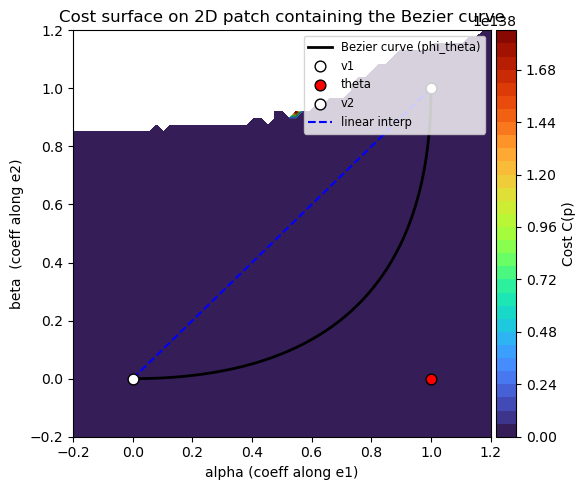

In [ ]:
# ---------------------------
# Plot 2D contour of cost on a 2D patch that contains the Bezier curve,
# then overlay the Bezier curve phi_theta(t) on top (like the middle panel).
# ---------------------------
import matplotlib.pyplot as plt
import numpy as np
import torch

# assume v1, v2, theta_opt, trajectory_loss, phi_theta_scalar_t, device are defined
# if theta_opt is a torch tensor, ensure on correct device and dtype
theta_vec = theta_opt.to(device).type(torch.float64)  # learned control point

# basis directions in parameter space (span that contains the quadratic Bezier)
e1 = (theta_vec - v1).detach()   # direction from v1 -> theta
e2 = (v2 - theta_vec).detach()   # direction from theta -> v2

# grid resolution
n_grid = 61   # 61x61 grid; reduce if it's slow
margin = 0.2  # extend patch beyond [0,1] to visualize surrounding loss

alphas = np.linspace(-margin, 1.0 + margin, n_grid)
betas  = np.linspace(-margin, 1.0 + margin, n_grid)

# preallocate cost grid
cost_grid = np.zeros((n_grid, n_grid), dtype=float)

# Evaluate loss on grid. Use torch.no_grad to avoid building big compute graph.
print("Evaluating cost on grid... (this may take a bit)")
with torch.no_grad():
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            # build parameter vector p = v1 + a*e1 + b*e2
            p_vec = v1 + a * e1 + b * e2
            # compute trajectory loss (must be the same function used in training)
            # trajectory_loss returns a torch scalar
            loss_val = trajectory_loss(p_vec, x_data)   # uses RK4 and x_data precomputed
            cost_grid[j, i] = float(loss_val)  # note: matplotlib expects y index first

print("Grid evaluation done.")

# Now compute coordinates of Bezier curve points mapped to (alpha,beta)
# For each t, compute phi(t) (a parameter vector) and solve for (a,b) such that v1 + a*e1 + b*e2 = phi(t)
# This is solving 11-dim linear system in two unknowns; we solve least-squares per point.
ts_curve = np.linspace(0.0, 1.0, 121)
curve_ab = []
phi_points = []
with torch.no_grad():
    E = torch.stack([e1, e2], dim=1)  # shape (P, 2)
    # We'll solve least squares for coefficients [a,b] minimizing ||E [a,b] - (phi - v1)||_2
    # closed form: (E^T E)^{-1} E^T (phi - v1)
    # compute (E^T E)^{-1} E^T once (P=11 small so fine)
    ET_E = (E.T @ E).cpu().numpy()  # 2x2
    inv_ET_E = np.linalg.inv(ET_E + 1e-12 * np.eye(2))
    ET = E.cpu().numpy().T  # 2 x P

    for t in ts_curve:
        p_phi = phi_theta_scalar_t(t, theta_vec)  # torch tensor length P
        rhs = (p_phi - v1).cpu().numpy()          # length P
        coeffs = inv_ET_E @ (ET @ rhs)            # 2-vector [a,b] least-squares solution
        curve_ab.append(coeffs)
        phi_points.append(p_phi.cpu().numpy())

curve_ab = np.array(curve_ab)   # shape (len(ts), 2)

# Create contour plot
A, B = np.meshgrid(alphas, betas)
fig, ax = plt.subplots(figsize=(6,5))

# Plot filled contours (choose levels or use log scaling if wide range)
levels = 30
cs = ax.contourf(A, B, cost_grid, levels=levels, cmap='turbo')
cbar = fig.colorbar(cs, ax=ax, pad=0.01)
cbar.set_label("Cost C(p)")

# Overlay contour lines for readability
ax.contour(A, B, cost_grid, levels=8, colors='k', linewidths=0.5, alpha=0.6)

# plot Bezier curve in (a,b)
ax.plot(curve_ab[:,0], curve_ab[:,1], color='black', lw=2, label='Bezier curve (phi_theta)')
# mark endpoints and control point
# Solve for coords of v1, theta_vec, v2 in (a,b):
def solve_ab_for_param(pvec):
    rhs = (pvec - v1).cpu().numpy()
    return inv_ET_E @ (ET @ rhs)

v1_ab = solve_ab_for_param(v1)
theta_ab = solve_ab_for_param(theta_vec)
v2_ab = solve_ab_for_param(v2)
ax.scatter([v1_ab[0]], [v1_ab[1]], c='white', edgecolor='k', s=60, zorder=5, label='v1')
ax.scatter([theta_ab[0]], [theta_ab[1]], c='red', edgecolor='k', s=60, zorder=6, label='theta')
ax.scatter([v2_ab[0]], [v2_ab[1]], c='white', edgecolor='k', s=60, zorder=5, label='v2')

# optionally plot the straight linear interpolation (v1 -> v2) in ab coords
lin_ts = np.linspace(0.0, 1.0, 41)
lin_ab = [solve_ab_for_param(v1 + s*(v2 - v1)) for s in lin_ts]
lin_ab = np.array(lin_ab)
ax.plot(lin_ab[:,0], lin_ab[:,1], color='blue', linestyle='--', label='linear interp')

ax.set_xlabel("alpha (coeff along e1)")
ax.set_ylabel("beta  (coeff along e2)")
ax.set_title("Cost surface on 2D patch containing the Bezier curve")
ax.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()
